# Post Hoc Power Analysis

## Setup

In [ ]:

library(here)


here() starts at E:/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

The post hoc analysis is based on the real dataset from Rogers ([2022](#ref-rogers2022)), publicly available in Mendeley Data. The data contain WHOQOL-BREF responses from 1,047 participants and are loaded directly from the repository URL. The sample size is extracted from the object and reused throughout this section, and the model degrees of freedom are computed from `analyzemodel` as a required input for the analytical functions.

In [ ]:

url_data <- "https://data.mendeley.com/datasets/rdky78bk8r/2/files/b58a7054-4978-4239-81db-00f9efd86e44/WHOQOL_Data.dat"
realdata <- read.table(url_data)

url_labels <- "https://data.mendeley.com/datasets/rdky78bk8r/2/files/ae2a5c01-2fc2-43e5-b31c-8db8cc5bff8a/WHOQOL_Labels.txt"
column_labels <- read.table(url_labels)
column_labels <- column_labels$V1
names(realdata) <- gsub("_[FPSA]$", "", column_labels)

n_real <- nrow(realdata) # Sample size of the real data

df_model <- 245 # Degrees of freedom with std.lv = TRUE


## Post hoc power analysis

### With simulation

Post hoc simulation-based power analysis follows four steps: fit the analysis model to the real data to obtain the empirical parameter estimates; simulate data from that fitted model to construct the null reference distribution; simulate data from the misspecified model to construct the alternative distribution; and evaluate how well each fit index separates the two distributions at the observed $N$ ([Pornprasertmanit et al., 2021](#ref-simsem2021); [Wang & Rhemtulla, 2021](#ref-wang2021)).

Grounding the reference distribution in the fitted model rather than in the theoretical population model is what distinguishes this from the a priori analyses above: here, the population structure is implied by the data rather than specified in advance, which makes the power estimate reflect the evidence actually available in the collected sample ([Feng & Hancock, 2023](#ref-feng2023); [Jobst et al., 2023](#ref-jobst2023)).

In [ ]:

fit_real <- cfa(
  analyzemodel,
  data      = realdata,
  estimator = "mlr",
  std.lv    = TRUE
)


In [ ]:

realmodel_null <- cache_or_run("realmodel_null", {
  sim(
      nRep      = REP,        # See the `REP` object defined in helpers.R for the number of replications used in this scenario.
      n         = n_real,
      analyzemodel,
      generate  = fit_real,
      std.lv    = TRUE,
      lavaanfun = "cfa",
      estimator = "mlr",
      seed      = SEED,
      multicore = TRUE
  )
})


In [ ]:

h1model_alt <- cache_or_run("h1model_alt", {
  sim(
      nRep      = REP,        # See the `REP` object defined in helpers.R for the number of replications used in this scenario.
      n         = n_real,
      analyzemodel,
      generate  = h1model,
      std.lv    = TRUE,
      lavaanfun = "cfa",
      estimator = "mlr",
      seed      = SEED,
      multicore = TRUE
  )
})


The figure below displays the fit-index distributions for the alternative and null conditions, alongside the empirical cutoff derived from the reference model at $\alpha$. The degree of visual separation between the two distributions provides an intuitive picture of whether the observed $N$ is sufficient to support reliable model discrimination ([McNeish & Wolf, 2021](#ref-mcneish2021); [Pornprasertmanit et al., 2021](#ref-simsem2021)).

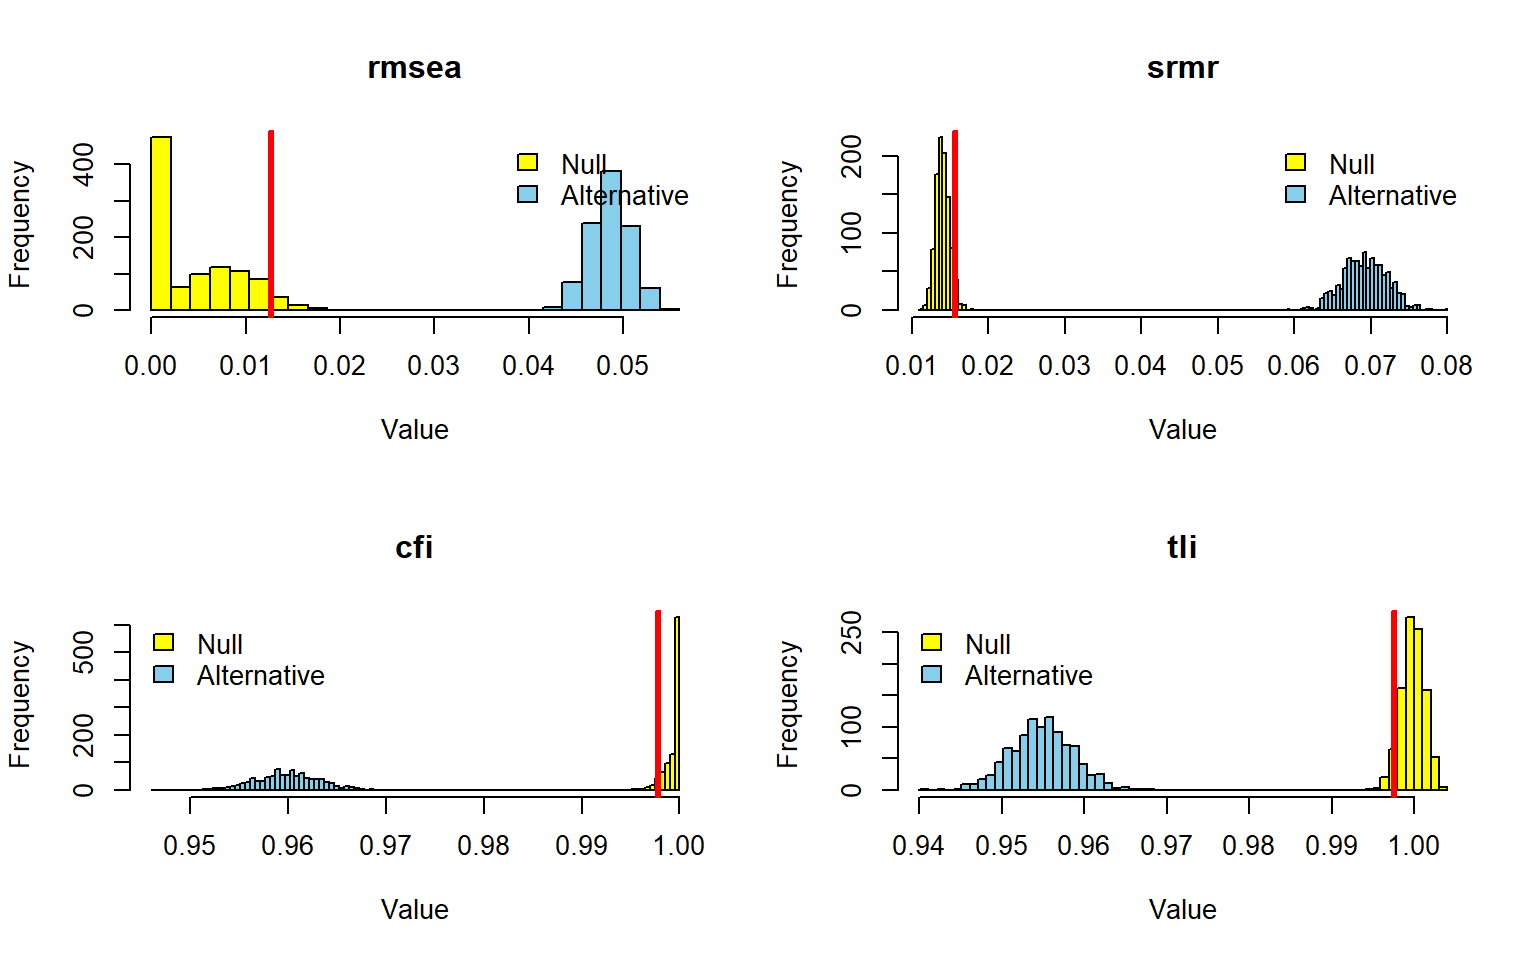

In [ ]:

# Plot the fit-index distributions for the alternative model and compare them
# with cutoffs obtained from the null model at level alpha.
# In simsem, this visualizes how well the selected global fit indices separate
# data generated under the null and alternative conditions.

plotPowerFit(
    h1model_alt,
    nullObject = realmodel_null,
    alpha      = ALPHA,
    usedFit    = FITS
)


The table below reports the corresponding power values for each index: the proportion of alternative-condition replications that fall beyond the null-model cutoff at the chosen $\alpha$ level ([Pornprasertmanit et al., 2021](#ref-simsem2021); [Wang, 2023](#ref-wang2023)).

In [ ]:

# Return post hoc power for each selected fit index.
# The cutoffs are internally derived from the null-object distribution,
# so the table summarizes the empirical rejection rate of the alternative model
# under the chosen set of fit criteria.

posthoc_pow <- getPowerFit(
    h1model_alt,
    nullObject = realmodel_null,
    alpha      = ALPHA,
    usedFit    = FITS
)

# Subset power to the four requested fit indices (FITS: rmsea, srmr, cfi, tli)
# ensuring TRADITIONALCHI is excluded.
posthoc_pow_clean <- posthoc_pow[FITS]

knitr::kable(
  as.data.frame(t(as.numeric(posthoc_pow_clean))),
  col.names = toupper(FITS),
  digits = 3,
  align = "c"
)


   RMSEA   SRMR   CFI   TLI
  ------- ------ ----- -----
     1      1      1     1


### With semPower

For comparison, the same post hoc question is addressed analytically through three specifications of increasing specificity. The first is model-free and sets the target discrepancy at $\text{RMSEA} = 0.05$; the second is model-based and derives the effect from the discrepancy between the misspecified population model (`h1model`) and the empirically fitted model; the third specifies an explicit nested-model comparison by supplying both a null and an alternative model, so the effect reflects a targeted structural difference rather than global misfit against the saturated model ([Jak et al., 2021](#ref-jak2021); [Moshagen & Bader, 2024](#ref-moshagen2024)).


 semPower: Post hoc power analysis
                                      
 F0                       0.612500    
 RMSEA                    0.050000    
 Mc                       0.736203    
 GFI                      0.951437    
 AGFI                     0.940535    
                                      
 df                       245         
 Num Observations         1047        
 NCP                      640.6750    
                                      
 Critical Chi-Square      282.5114    
 Alpha                    0.050000    
 Beta                     3.070697e-47
 Power (1 - Beta)         > 0.9999    
 Implied Alpha/Beta Ratio 1.628295e+45

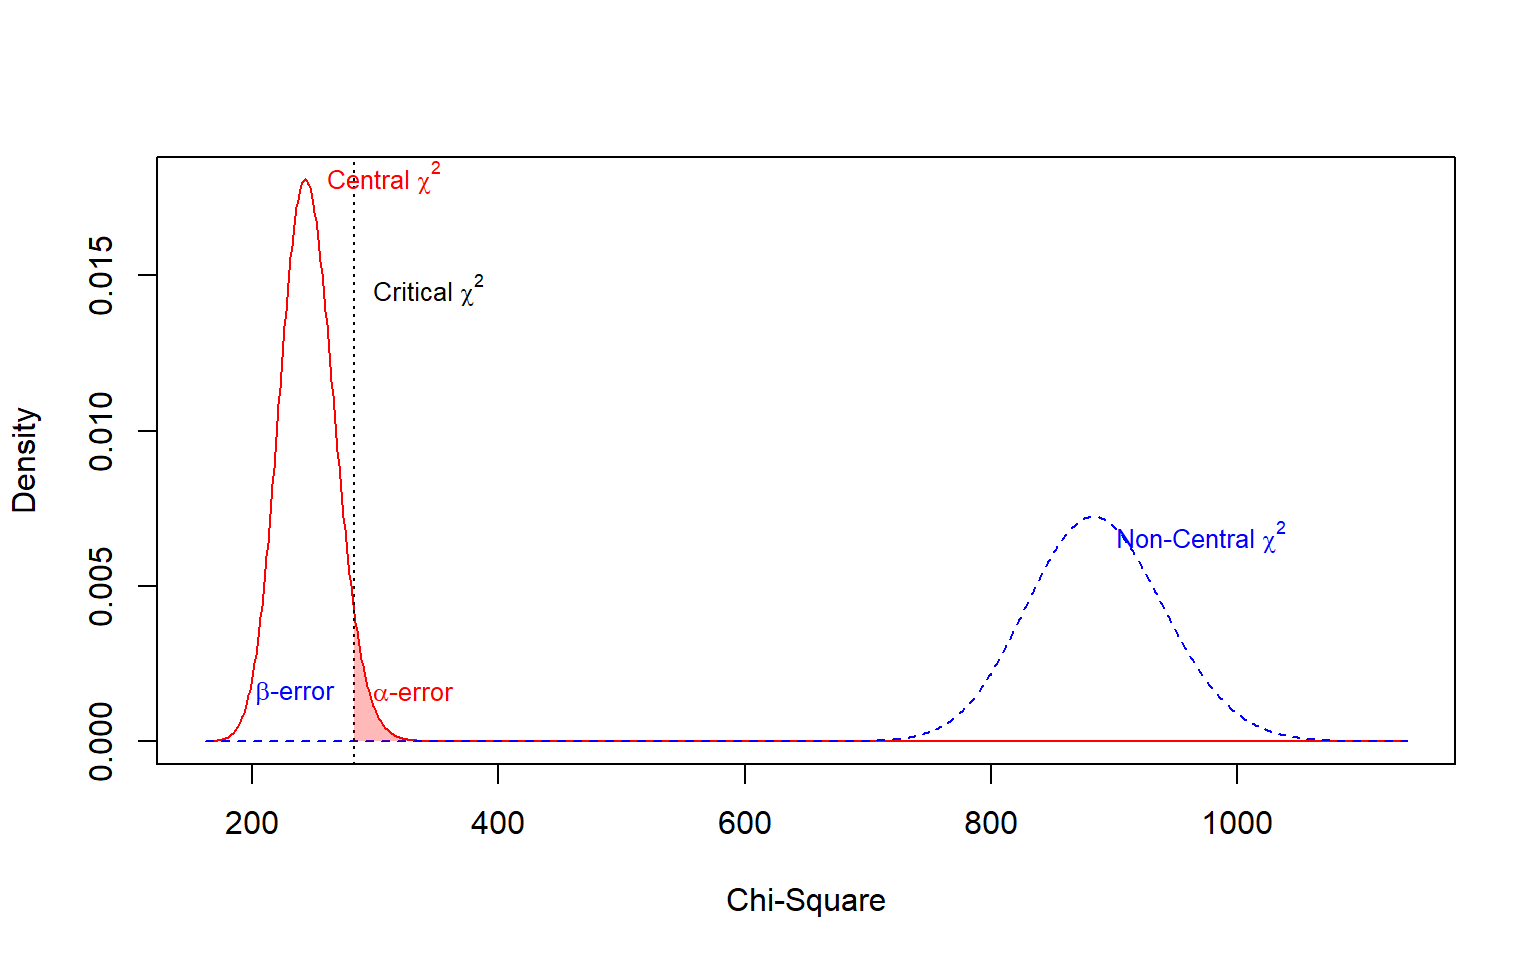

In [ ]:

# Analytical post hoc power for a global fit test.
# The target effect is fixed directly as RMSEA = 0.05.
# H0 is exact fit, alpha is 0.05, and the sample size is 1,047.

ph_rmsea <- semPower::semPower.postHoc(
  effect         = 0.05,
  effect.measure = "RMSEA",  # Target discrepancy expressed as RMSEA
  alpha          = ALPHA,
  N              = n_real,
  df             = df_model,
  p              = P         # Only relevant for indices such as GFI and AGFI
)

summary(ph_rmsea)


In the model-based specification below, `semPower.powerLav()` fits the analysis model to the population-implied covariance matrix and translates the resulting discrepancy into the noncentrality parameter. Because `modelH1` is omitted, the comparison is against the saturated model, making this a global test of fit rather than a test of a specific restriction ([Jobst et al., 2023](#ref-jobst2023); [Moshagen & Bader, 2024](#ref-moshagen2024)).


 semPower: Post hoc power analysis
                                      
 F0                       0.578978    
 RMSEA                    0.048612    
 SRMR                     0.066543    
 Mc                       0.748646    
 GFI                      0.953973    
 AGFI                     0.943640    
 CFI                      0.959955    
                                      
 df                       245         
 Num Observations         1047        
 NCP                      605.6108    
                                      
 Critical Chi-Square      282.5114    
 Alpha                    0.050000    
 Beta                     1.868864e-43
 Power (1 - Beta)         > 0.9999    
 Implied Alpha/Beta Ratio 2.675422e+41

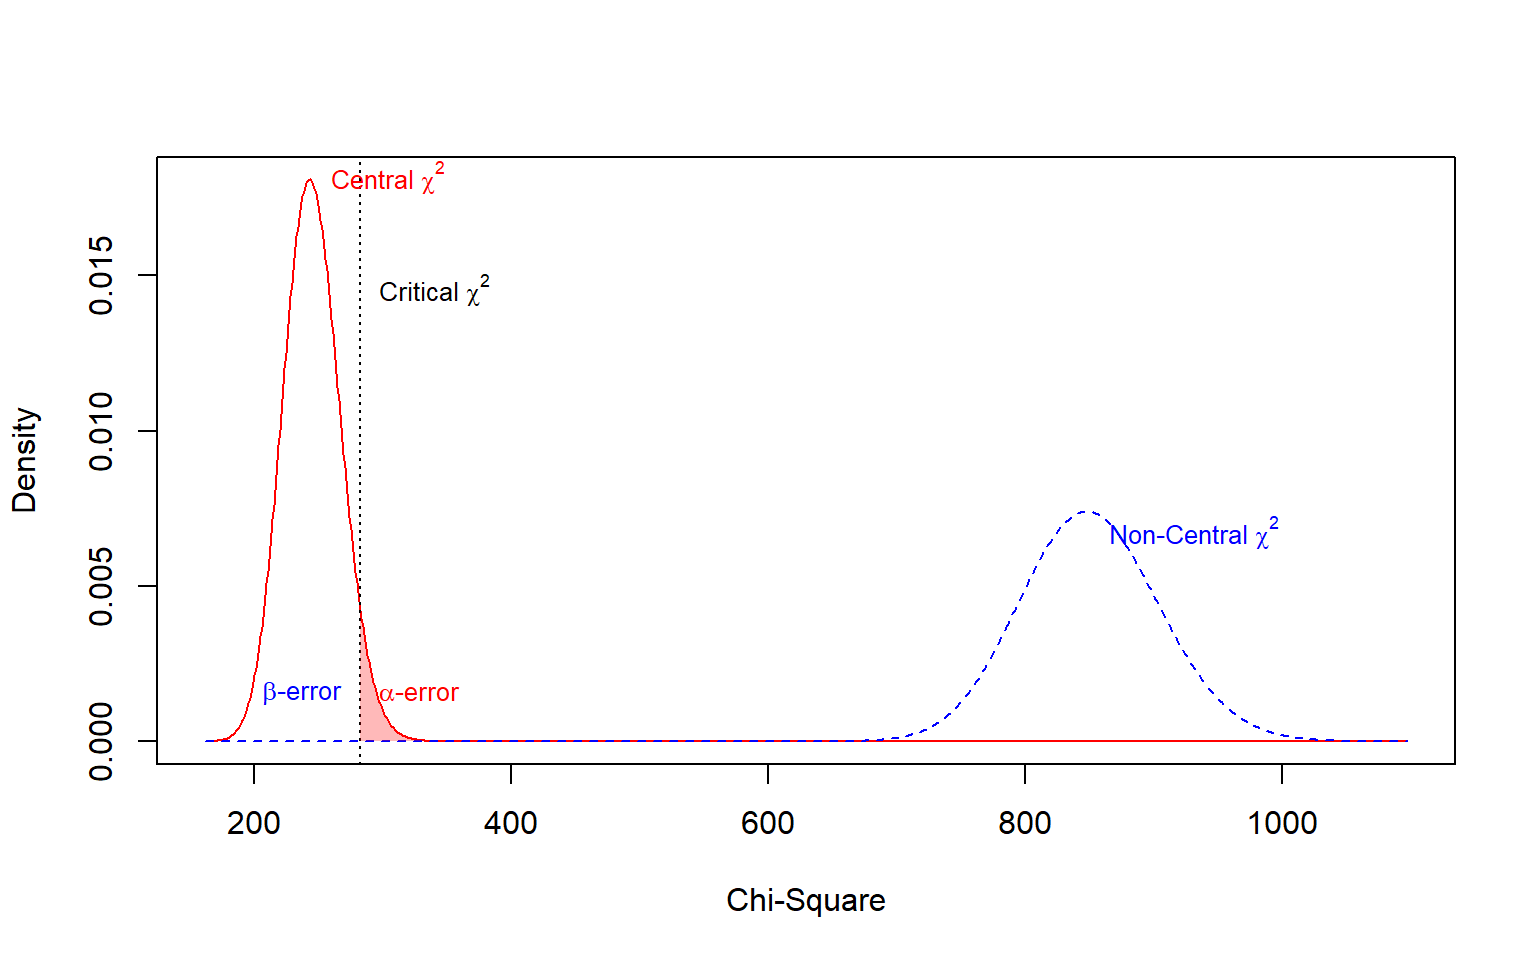

In [ ]:

# Analytical post hoc power based on lavaan models.
# modelPop defines the population structure (h1model with cross-loadings).
# modelH0 is the focal model to be tested.
# Because modelH1 is omitted, the comparison is against the saturated model.

ph_realmodel <- semPower::semPower.powerLav(
  type       = "post-hoc",
  alpha      = ALPHA,
  N          = n_real,
  modelPop   = h1model,
  modelH0    = fit_real,
  lavOptions = list(std.lv = TRUE)
)

summary(ph_realmodel)


Feng, Y., & Hancock, G. R. (2023). Power Analysis within a Structural Equation Modeling Framework. In R. H. Hoyle (Ed.), *Handbook of Structural Equation Modeling*. The Guilford Press.

Jak, S., Jorgensen, T. D., Verdam, M. G. E., Oort, F. J., & Elffers, L. (2021). Analytical power calculations for structural equation modeling: A tutorial and Shiny app. *Behavior Research Mehods*, *53*, 1385–1406. <https://doi.org/10.3758/s13428-020-01479-0/Published>

Jobst, L. J., Bader, M., & Moshagen, M. (2023). A tutorial on assessing statistical power and determining sample size for structural equation models. *Psychological Methods*, *28*(1), 207–221. <https://doi.org/10.1037/met0000423>

McNeish, D., & Wolf, M. G. (2021). Dynamic fit index cutoffs for confirmatory factor analysis models. *Psychological Methods*, *28*(1), 61–88. <https://doi.org/10.1037/met0000425>

Moshagen, M., & Bader, M. (2024). <span class="nocase">semPower</span>: General power analysis for structural equation models. *Behavior Research Methods*, *56*(4), 2901–2922. <https://doi.org/10.3758/s13428-023-02254-7>

Pornprasertmanit, S., Miller, P., Schoemann, A., & Jorgensen, T. D. (2021). *Simsem: SIMulated Structural Equation Modeling*. <https://CRAN.R-project.org/package=simsem>

Rogers, P. (2022). Best Practices for Your Exploratory Factor Analysis: A Factor Tutorial. *Revista de Administração Contemporânea*, *26*(6). <https://doi.org/10.1590/1982-7849rac2022210085.en>

Wang, Y. A. (2023). *How to Conduct Power Analysis for Structural Equation Models: A Practical Primer* \[Preprint\]. PsyArXiv. <https://doi.org/10.31234/osf.io/4n3uk>

Wang, Y. A., & Rhemtulla, M. (2021). Power Analysis for Parameter Estimation in Structural Equation Modeling: A Discussion and Tutorial. *Advances in Methods and Practices in Psychological Science*, *4*(1), 1–17. <https://doi.org/10.1177/2515245920918253>